# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [111]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [112]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_value_col = df.isnull().mean(axis = 0).sort_values(ascending = False)
print("Ty le missing theo tung cot: ")
print(missing_value_col)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "deck", "embark_town", "adult_male", "who", "class", "alone"]   # danh sách cột cần bỏ
df = df.drop(columns = leaky)

print("Cac cot con lai:", list(df.columns))

Ty le missing theo tung cot: 
deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
sex            0.000000
pclass         0.000000
survived       0.000000
fare           0.000000
parch          0.000000
sibsp          0.000000
class          0.000000
adult_male     0.000000
who            0.000000
alive          0.000000
alone          0.000000
dtype: float64
Cac cot con lai: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c :**

VÌ SAO `alive` GÂY RÒ RỈ TARGET: 
+ Cột **alive** ("yes"/"no") chính là giá trị survived (1/0) khi được viết lại dưới dạng chữ. 
+ Nếu để **alive** làm đặc trưng đầu vào (X) trong khi **survived** là nhãn cần dự đoán (y), thì mô hình chỉ cần lấy dữ liệu từ alive rồi suy ra survived tương ứng. Kết quả: tuy giá trị accuracy trên tập train/test sẽ cao nhưng mô hình không hề học được mối quan hệ thực sự giữa các đặc trưng giữa độ tuổi, giới tính, hạng vé,... đến tỷ lệ sống sót,.... **Ví dụ:** Những người đàn ông trung niên thì không được ưu tiên lên thuyền nên tỷ lệ sống sót thấp.
+ Khi đưa mô hình này vào thực tế mô hình sẽ hoàn toàn vô dụng vì nó chưa từng học cách dự đoán từ các đặc trưng thật sự.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [113]:
# TODO 2: shape, info, describe
so_hang , so_cot = df.shape
print("So hang cua du lieu: " , so_hang)
print("So hang cua du lieu: " , so_cot)
print ("Bien target: survived (1 : con song , 0 : khong con song)")
print()

# Xem kiểu dữ liệu và số giá trị non-null
df.info()

# Phân biệt các cột là biến số và biến phân loại
print("\nThong ke cac cot la bien so:\n")
display(df.describe())
print("\nThong ke cac cot la bien phan loai:\n")
display(df.describe(include = "object"))

So hang cua du lieu:  891
So hang cua du lieu:  8
Bien target: survived (1 : con song , 0 : khong con song)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

Thong ke cac cot la bien so:



,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Thong ke cac cot la bien phan loai:



,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2:**

BIẾN SỐ VÀ BIẾN PHÂN LOẠI
- **Biến số(numeric)**: age(tuổi, biến liên tục), sibsp(số anh/chị/em + vợ/chồng đi cùng, biến rời
rạc), parch (số cha/mẹ + con đi cùng, biến rời rạc), fare (giá vé, biến liên tục).
- **Biến phân loại(categorical)**: sex (nam/nữ), embarked (cảng lên tàu: C/Q/S).
- Biến **survived(1/0)** tuy là biến số nhưng thực chất là **biến phân loại nhị phân**, còn biến **pclass(1/2/3)** lại chính là **biến phân loại thứ bậc**.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [114]:
# TODO 3: bảng missing (count + %)
# Tổng số missing value theo cột
missing_value_count = df.isnull().sum(axis = 0)
# Tỷ lệ % của missing value theo cột
percentage_missing_value = (df.isnull().mean(axis = 0) * 100).round(2)

# Lập bảng missing
bang_missing = pd.DataFrame({
        "Tong so missing value cua cot" : missing_value_count,
        "Ty le phan tram (%)" : percentage_missing_value
})
bang_missing = bang_missing[bang_missing["Tong so missing value cua cot"] > 0].sort_values("Ty le phan tram (%)", ascending = False)
print(bang_missing)
print("Gia tri skewness cua cot age:" , df["age"].skew().round(2))

          Tong so missing value cua cot  Ty le phan tram (%)
age                                 177                19.87
embarked                              2                 0.22
Gia tri skewness cua cot age: 0.39


**Trả lời 3:**

ĐỀ XUẤT XỬ LÝ CHO TỪNG CỘT THIẾU
| Cột | % thiếu | Cách xử lý đề xuất | Lý do |

* Cột **age** (biến số liên tục):
  + Tỷ lệ thiếu: xấp xỉ 19.87%.
  + Đề xuất cách xử lý: điền median.
  + Lý do: biến số **age** không phải là biến target, tỷ lệ thiếu theo cột thì không đủ lớn để xoá, đồng thời dữ liệu của biến số **age** lệch phải (chỉ số skewness = 0.39 > 0) do có một số vị khách lớn tuổi nên ta điền meadian thay vì mean để bền vững hơn với outlier.
* Cột **embarked** (C/Q/S):
  + Tỷ lệ thiếu: xấp xỉ 0.22%.
  + Đề xuất cách xử lý: điền mode.
  + Lý do: biến số **embarked** là biến phân loại, tỷ lệ thiếu là rất ít nên điền mode sẽ không ảnh hường nhiều đến phân phối chung của biến.

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [115]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
# Tính theo IQR
def dem_outlier_iqr(s):
    s = s.dropna()
    s_q1 = s.quantile(0.25)
    s_q3 = s.quantile(0.75)
    
    s_iqr = s_q3 - s_q1
    can_duoi = s_q1 - 1.5 * s_iqr
    can_tren = s_q3 + 1.5 * s_iqr
    
    tong_outlier_iqr = ((s < can_duoi) | (s > can_tren)).sum()
    return tong_outlier_iqr , can_duoi, can_tren

# Tính theo z_score
def dem_outlier_zscore(s, nguong = 3.0):
    z_scores = np.abs(stats.zscore(s.dropna()))
    tong_outlier_zscore = (z_scores > nguong).sum()
    return tong_outlier_zscore

# In số outlier tính theo iqr và z_score cho hai đặc trưng
for col in ["age", "fare"]:
    iqr, low, high = dem_outlier_iqr(df[col])
    zscores = dem_outlier_zscore(df[col])
    print(f"Cot {col}:")
    print(f" - IQR : {iqr} outlier (ngoài [{low:.1f}, {high:.1f}])")
    print(f" - Z-score : {zscores} outlier (|z-score| > 3)")
    print()

Cot age:
 - IQR : 11 outlier (ngoài [-6.7, 64.8])
 - Z-score : 2 outlier (|z-score| > 3)

Cot fare:
 - IQR : 116 outlier (ngoài [-26.7, 65.6])
 - Z-score : 20 outlier (|z-score| > 3)



**Trả lời 4:**

QUYẾT ĐỊNH: giữ lại các outlier của **fare**.
+ Các điểm dữ liệu của đặc trưng này có giá trị cao bất thường không phải do lỗi nhập liệu mà là vé của những
hành khách đi hạng nhất (pclass = 1), nhóm này trả giá vé cao hơn hẳn phần còn lại.
+ Vì thế, nếu bỏ đi các outlier của **fare** thì vô tình xóa mất chính nhóm hành khách giàu có, đóng vai trò quan trọng khi xét đến sự tương quan với tỷ lệ sống sót (ở tầng cao và gần phao cứu sinh hơn). 

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

Gia tri skewness cua cot age: 0.39
Gia tri skewness cua cot fare: 4.79



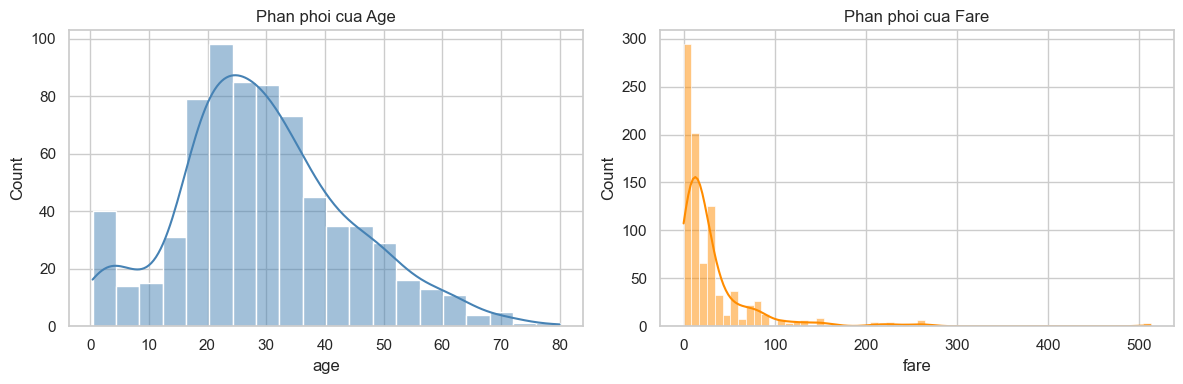

In [116]:
# TODO 5a: Histogram age & fare
print("Gia tri skewness cua cot age:" , df["age"].skew().round(2))
print("Gia tri skewness cua cot fare:" , df["fare"].skew().round(2))
print()

fig, axes = plt.subplots(1, 2, figsize = (12 , 4))
# Histogram của đặc trung age
sns.histplot(df["age"], kde = True, ax = axes[0], color = "steelblue")
axes[0].set_title("Phan phoi cua Age")
axes[0].set_xlabel("age")

# Histogram của đặc trung fare
sns.histplot(df["fare"], kde = True, ax = axes[1], color = "darkorange")
axes[1].set_title("Phan phoi cua Fare")
axes[1].set_xlabel("fare")

plt.tight_layout()
plt.show()

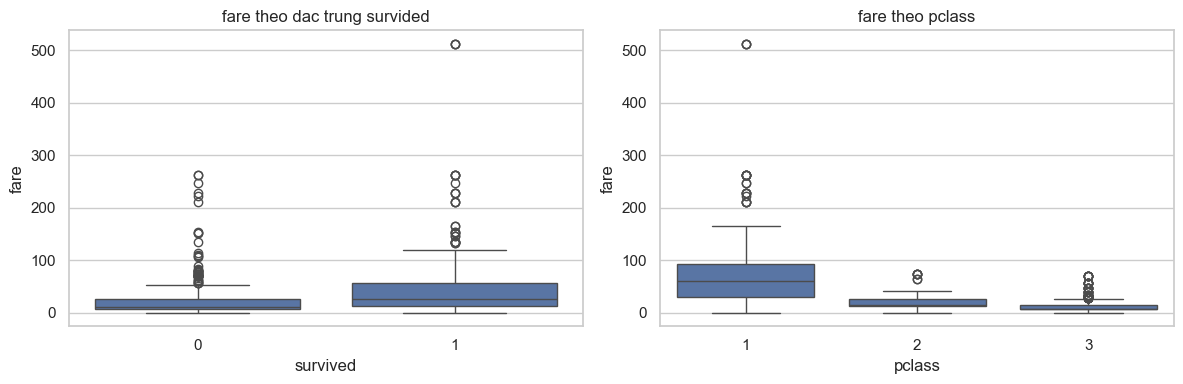

In [117]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize = (12 , 4))

sns.boxplot(data = df, x = "survived", y = "fare", ax = axes[0])
axes[0].set_title("fare theo dac trung survided")

sns.boxplot(data = df, x = "pclass", y = "fare", ax = axes[1])
axes[1].set_title("fare theo pclass")

plt.tight_layout()
plt.show()

Ty le song sot theo sex:
sex
female    0.74
male      0.19
Name: survived, dtype: float64

Ty le song sot theo pclass:
pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64


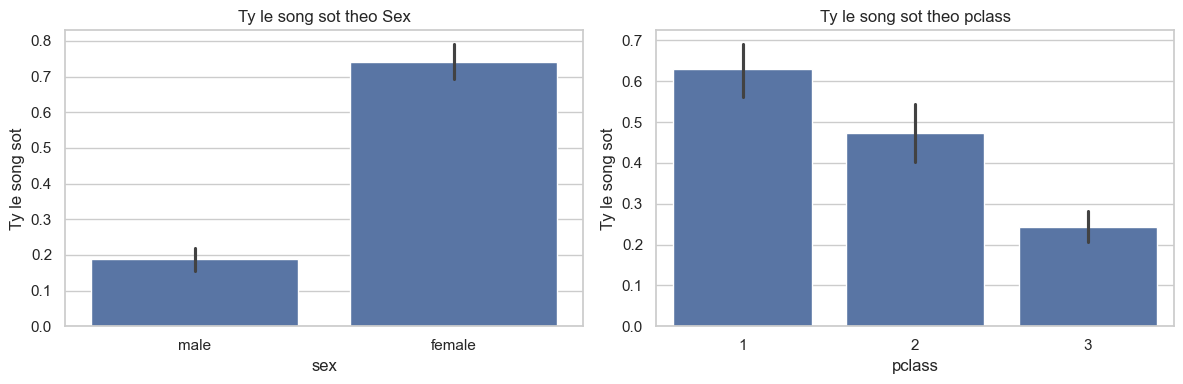

In [118]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize = (12 , 4))

print("Ty le song sot theo sex:")
print(df.groupby("sex")["survived"].mean().round(2))
print("\nTy le song sot theo pclass:")
print(df.groupby("pclass")["survived"].mean().round(2))

sns.barplot(data = df, x = "sex", y = "survived", ax = axes[0])
axes[0].set_title("Ty le song sot theo Sex")
axes[0].set_ylabel("Ty le song sot")

sns.barplot(data = df, x = "pclass", y = "survived", ax = axes[1])
axes[1].set_title("Ty le song sot theo pclass")
axes[1].set_ylabel("Ty le song sot")

plt.tight_layout()
plt.show()

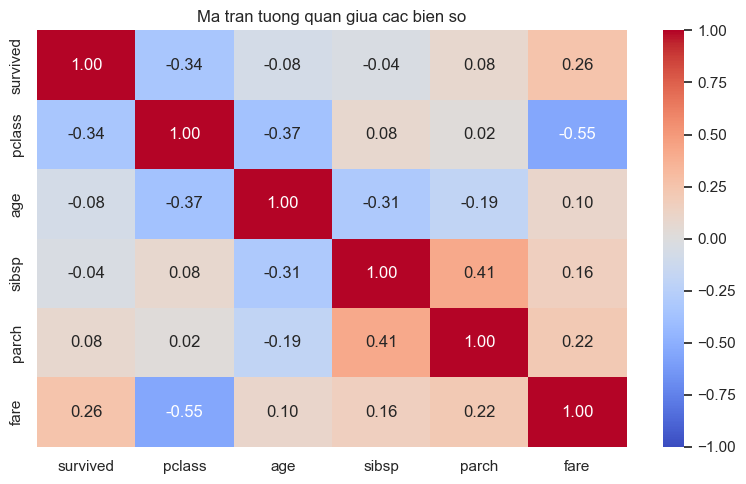

In [119]:
# TODO 5d: Heatmap correlation
ma_tran_bien_so = df.select_dtypes(include = "number")
ma_tran_tuong_duong = ma_tran_bien_so.corr()

plt.figure(figsize = (8 , 5))
sns.heatmap(ma_tran_tuong_duong, vmin = -1, vmax = 1, cmap = "coolwarm", annot = True, fmt = ".2f", center = 0)
plt.title("Ma tran tuong quan giua cac bien so")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

ĐỐI VỚI CÁC BIỂU ĐỒ:
1. **Histogram**:
   + **age** có phân phối tương đối gần tuân theo phân phối chuẩn, hơi lệch phải nhẹ (đa số hành khách có tuổi từ 20 - 35 tuổi, một số ít người lớn tuổi từ 60 - 80 tuổi kéo đuôi phân phối sang phải).
   + **fare** lệch phải mạnh (skewness = 4.79): phần lớn hành khách mua vé với giá thấp (dưới 30), nhưng có một nhóm nhỏ trả giá vé rất cao (trên 150$), tạo ra đuôi dài bên phải.
2. **Boxplot**:
   + Theo **survived**, nhóm survived = 1 có **fare** cao hơn rõ rệt so với nhóm survived = 0 , hiểu rằng: người trả vé cao hơn có khả năng sống sót cao hơn. Nhưng cũng có rất nhiều outlier xuất hiện, cho thấy tỷ lệ sống sót còn phụ thuộc vào rất nhiều đặc trưng chớ không chỉ **fare**.
   + Theo **pclass** , hạng 1 có giá trị trung vị của **fare** cao hơn hẳn hạng 2 và hạng 3, tầng lớp thượng có xu hướng mua vé đắt hơn so với các tầng lớp khác, phản ánh vấn đề liên quan "kinh tế - xã hội"; cả ba nhóm đều có khá nhiều outlier phía trên, đặc biệt là hạng 1.
3. **Barplot**:
   + Nữ giới có tỷ lệ sống sót khoảng 74.2%, trong khi nam giới chỉ khoảng 18.9% (ưu tiên "phụ nữ và trẻ em trước"), suy ra: giới tính là yếu tố ảnh hưởng rất mạnh đến tỷ lệ sống sót.
   + Theo hạng vé, hạng 1 có tỷ lệ sống sót khoảng 63%, hạng 2 khoảng 47%, hạng 3 khoảng 24%: hạng vé càng cao thì tỷ lệ sống càng lớn.
4. **Heatmap**:
   + **survived** tương quan âm với **pclass** (khoảng -0.55) và tương quan dương với **fare** (khoảng 0.26).
   + Các biến sibsp, parch có tương quan không quá mạnh với **survived** (người thân thì có xu hướng tìm nhau và cùng nhau đi nên khả năng sống sót nhỏ).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [120]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns = "survived")
y = df["survived"]

# Chia tập theo tỷ lệ 70 - 15 - 15
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, stratify = y, test_size = 0.15, random_state = 42)
# test_size lần 2: 0.15 * y = test_size * y_tmp (0.85 * y)  => test_size = 0.15 / 0.85 = 0.1765
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, stratify = y_tmp, test_size = 0.1765, random_state = 42)

# print("Train/Val/Test:", ...)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
# in tỷ lệ survived từng tập
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f" Tỷ lệ survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
 Tỷ lệ survived (train): 0.384
 Tỷ lệ survived (val): 0.388
 Tỷ lệ survived (test): 0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [121]:
num_cols = ["age", "sibsp", "parch", "fare"]    # dữ liệu số 
cat_cols = ["sex", "embarked"]                  # dữ liệu chữ
ord_cols = ["pclass"]                           # dữ liệu thứ tự

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", RobustScaler())
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)                       # fit CHỈ trên train
Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)
print("Sau tiền xử lý — train:", Xtr.shape, "| val:", Xva.shape, "| test:", Xte.shape)
print("Tên cột sau biến đổi:", list(preprocess.get_feature_names_out()))

Sau tiền xử lý — train: (623, 8) | val: (134, 8) | test: (134, 8)
Tên cột sau biến đổi: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7:**

VÌ SAO **fit** CHỈ TRÊN TRAIN TRÁNH LEAKAGE:
+ Nếu ta **fit** trên toàn bộ dữ liệu (gồm cả tập **val** / **test**), thì các con số thống kê đó (median, IQR, mode,...) đã bị rò rỉ vào tập **train**, trong khi đúng ra tập test phải đóng vai trò dữ liệu hoàn toàn mới, mô phỏng tình huống thực tế.
+ Việc **fit** chỉ trên X_train đảm bảo mọi tham số tiền xử lý chỉ được học từ đúng phần dữ liệu mà mô hình được phép nhìn thấy khi huấn luyện. Đồng thời, **transform** trên X_val / X_test chỉ đơn thuần áp dụng lại công thức đã học, không học thêm gì mới, giữ cho quá trình đánh giá trên val / test phản ánh đúng khả năng tổng quát hoá của mô hình.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [122]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ty_le_class = df["survived"].value_counts(normalize = True)
print("Ty le hai class cua survived:")
print(ty_le_class.round(2))

Ty le hai class cua survived:
survived
0    0.62
1    0.38
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu survided có mất cân bằng không?
   + Có mất cân bằng nhẹ.
   + Tỷ lệ của class 1 xấp xỉ: 61.6% và tỷ lệ của class 0 xấp xỉ: 38.4%.
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
   + Xảy ra khi mô hình mất cân bằng.
   + Lúc này, mô hình "lười biếng" và luôn đoán là class có tỷ lệ cao hơn, từ đó tuy **Accuracy** tuy khá cao nhưng mô hình lại không học được gì và đoán sai với class có tỷ lệ thấp hơn.
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?
   + Với bài toán Titanic, ta nên ưu tiên **F1-score**.
   + Lý do:
      * Dữ liệu có mất cân bằng nên **Accuracy** chưa đủ tin cậy; đồng thời **F1** cân bằng giữa **Precision** (trong những người được dự đoán sống sót, bao nhiêu người thực sự sống sót) và Recall (trong những người thực sự sống sót, mô hình phát hiện được bao nhiêu người sống).
      * Phù hợp khi ta quan tâm đến cả hai loại sai số, không muốn dự đoán sai quá nhiều người sống trong khi họ không sống (Precision thấp) và bỏ sót những người thực sự sống sót (Recall thấp).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh):

Đặc trưng tương quan mạnh nhất với sống sót là pclass (tương quan khoảng -0.34) và fare (khoảng 
+0.26) — phản ánh yếu tố: địa vị kinh tế - xã hội.

2. Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?

Cột thiếu nhiều nhất trong tập dữ liệu gốc là **deck** (~77% thiếu) — đã được loại bỏ vì thiếu quá nhiều nên rất ít đáng tin cậy. Trong những đặc trưng được giữ lại, **age** là biến thiếu nhiều nhất (~19.87%), được xử lý bằng cách điền median; **embarked** là biến phân loại chỉ thiếu 2 dòng (~0.22%) nên được điền bằng mode.

3. Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?

Biến mục tiêu **survived** mất cân bằng nhẹ (61.6% với class 0 vs 38.4% cho class 1). Vì vậy, khi đánh giá mô hình: không nên chỉ dựa vào **Accuracy** mà cần xem thêm Precision/Recall/F1.

4. Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?

Các đặc trưng số liên tục như **age**, **fare**, **sibsp**, **parch** được điền khuyết và scaling (RobustScaler). Các đặc trưng phân loại không có thứ tự như sex , **embarked** cần **encoding** (One-Hot Encoding) vì mô hình không thể tính toán trực tiếp với dữ liệu dạng chữ; riêng **pclass** tuy là số nhưng mang ý nghĩa thứ tự nên được giữ nguyên (passthrough).

5. Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**fare** có rất nhiều giá trị outlier rất cao(116 outlier theo IQR), nhưng đây không phải lỗi dữ liệu mà là các vé hạng nhất. Từ đó ta nhận thấy rằng: Xử lý outlier không có một cách tổng quát cho mọi bài, nên phải kiểm tra dữ liệu thật kỹ trước khi quyết định giữ hay bỏ chúng.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [123]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
